In [1]:
import re
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set

import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

In [2]:
@dataclass(frozen=True)
class Flight:
    fid: int
    origin: str
    dest: str
    dep: float   # minutes
    arr: float   # minutes

In [9]:
def parse_flights(text: str) -> List[Flight]:
    # Matches: <1,MAD,HAM,6360.0,6615.0>
    # Airports: 2 to 4 uppercase letters (BCN, LGW, CDG, etc.)
    pat = re.compile(
        r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*,\s*([A-Z]{2,4})\s*,\s*([0-9.]+)\s*,\s*([0-9.]+)\s*>"
    )

    flights = []
    for m in pat.finditer(text):
        fid = int(m.group(1))
        o = m.group(2)
        d = m.group(3)
        dep = float(m.group(4))
        arr = float(m.group(5))
        flights.append(Flight(fid, o, d, dep, arr))

    flights.sort(key=lambda f: f.fid)
    return flights




def parse_cost_matrix(text: str) -> np.ndarray:
    # extracts the first Cost = [ ... ];
    pat = re.compile(r"Cost\s*=\s*\[(.*?\])\s*;\s*", re.DOTALL)  # greedy-ish until the first closing bracket
    m = pat.search(text)
    if not m:
        return np.array([])
    block = m.group(1)

    # Find all rows like [6804.0,6870.0,...]
    row_pat = re.compile(r"\[(.*?)\]")
    rows = []
    for rm in row_pat.finditer(block):
        row_str = rm.group(1).strip()
        if not row_str:
            continue
        vals = [float(x.strip()) for x in row_str.split(",") if x.strip()]
        rows.append(vals)
    return np.array(rows, dtype=float)
def parse_aircraft_bases(text: str) -> Dict[int, str]:
    pat = re.compile(r"Aircraft\s*=\s*\[(.*?)\];", re.DOTALL)
    m = pat.search(text)
    if not m:
        return {}

    block = m.group(1)
    pair_pat = re.compile(r"<\s*(\d+)\s*,\s*([A-Z]{2,4})\s*>")
    bases = {int(mm.group(1)): mm.group(2) for mm in pair_pat.finditer(block)}
    return bases

In [10]:
# === Cellule 3 (version fichier) ===

DATA_PATH = r"C:\Users\lechh\Tail_assignment\Data\d=0.9\DataCplex_density=0.9_p=10_h=7_test_0.dat"

with open(DATA_PATH, "r") as f:
    file_text = f.read()

flights = parse_flights(file_text)
bases = parse_aircraft_bases(file_text)
cost = parse_cost_matrix(file_text)

print("Nb flights parsed:", len(flights))
print("Nb aircraft bases parsed:", len(bases))
print("Cost shape:", cost.shape)

if flights:
    print("Example flight:", flights[0])
if bases:
    print("Example aircraft base:", list(bases.items())[:3])

Nb flights parsed: 167
Nb aircraft bases parsed: 10
Cost shape: (167, 10)
Example flight: Flight(fid=1, origin='MAD', dest='HAM', dep=6360.0, arr=6615.0)
Example aircraft base: [(0, 'HAM'), (1, 'HAM'), (2, 'BCN')]


In [6]:
print(file_text[:2000])

Airports =  {BCN,HAM,LGW,MAD,AMS,NCE,GLA,DUB,HEW,FRA,MXP,OSL,MUC,ZRH,BER,MAN,LUX,MRS,CDG,HEM,};
Nbflight = 167;
Aircrafts = {0,1,2,3,4,5,6,7,8,9,};
Flight = {
<1,MAD,HAM,6360.0,6615.0>
<2,HAM,LGW,2845.0,3045.0>
<3,NCE,HAM,1985.0,2090.0>
<4,LGW,MAD,3490.0,3695.0>
<5,HAM,FRA,9250.0,9390.0>
<6,FRA,HEW,9460.0,9565.0>
<7,HEW,BCN,9595.0,9740.0>
<8,BCN,MXP,9770.0,9945.0>
<9,MAD,LGW,3730.0,3990.0>
<10,HAM,LGW,620.0,825.0>
<11,LGW,MAN,905.0,1045.0>
<12,MAN,MXP,1115.0,1230.0>
<13,MXP,NCE,1300.0,1415.0>
<14,LGW,MAD,5530.0,5735.0>
<15,HAM,LGW,7820.0,8025.0>
<16,LGW,OSL,8110.0,8215.0>
<17,OSL,LGW,8245.0,8355.0>
<18,HEW,LGW,4930.0,5145.0>
<19,OSL,LGW,5365.0,5475.0>
<20,LGW,HEW,4100.0,4305.0>
<21,LGW,OSL,5230.0,5335.0>
<22,MUC,HAM,8605.0,8850.0>
<23,LGW,MUC,8425.0,8550.0>
<24,HAM,HEW,2370.0,2540.0>
<25,HAM,CDG,6700.0,6910.0>
<26,CDG,HAM,6985.0,7210.0>
<27,HEW,HAM,2660.0,2785.0>
<28,HAM,MAD,1135.0,1410.0>
<29,HAM,BCN,620.0,815.0>
<30,BCN,HAM,850.0,1105.0>
<31,OSL,LGW,8245.0,8355.0>
<32,MAD,LUX,2090.0,

In [16]:
def build_compatibility_edges(flights: List[Flight], tau: float) -> Set[Tuple[int,int]]:
    # index flights by origin for speed
    by_origin: Dict[str, List[Flight]] = {}
    for f in flights:
        by_origin.setdefault(f.origin, []).append(f)
    # sort by dep time in each bucket (optional)
    for k in by_origin:
        by_origin[k].sort(key=lambda x: x.dep)

    E = set()
    # map fid -> flight for later
    fid2 = {f.fid: f for f in flights}

    for fi in flights:
        candidates = by_origin.get(fi.dest, [])
        # check time feasibility
        earliest = fi.arr + tau
        for fj in candidates:
            if fj.dep >= earliest:
                E.add((fi.fid, fj.fid))
    return E

tau = 0
E = build_compatibility_edges(flights, tau)
print("Nb compatibility arcs:", len(E))

Nb compatibility arcs: 1389


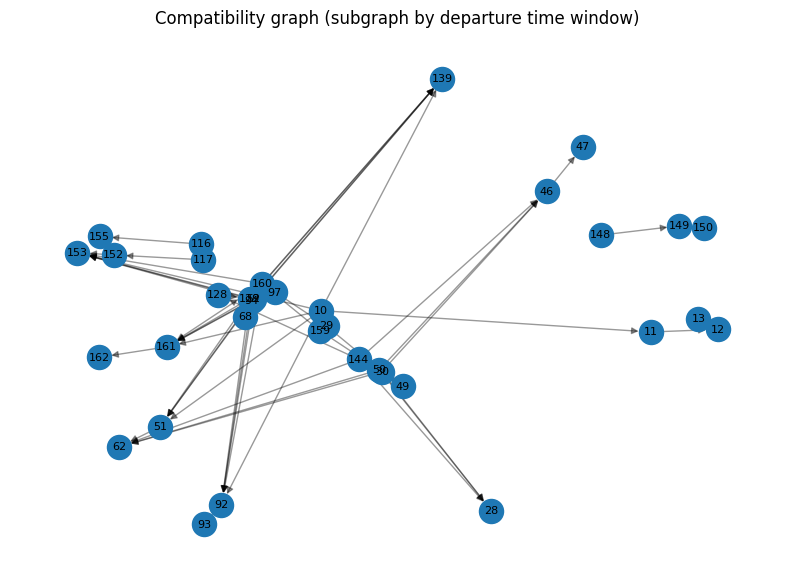

Nodes: 35 Edges: 58


In [17]:
def subgraph_by_time(flights: List[Flight], E: Set[Tuple[int,int]], tmin: float, tmax: float):
    ids = {f.fid for f in flights if (tmin <= f.dep <= tmax)}
    G = nx.DiGraph()
    for fid in ids:
        G.add_node(fid)
    for (i,j) in E:
        if i in ids and j in ids:
            G.add_edge(i,j)
    return G

# window example: first 1500 minutes
G_small = subgraph_by_time(flights, E, 0, 1500)

plt.figure(figsize=(10,7))
pos = nx.spring_layout(G_small, seed=0)
nx.draw_networkx_nodes(G_small, pos, node_size=300)
nx.draw_networkx_edges(G_small, pos, arrows=True, alpha=0.4)
nx.draw_networkx_labels(G_small, pos, font_size=8)
plt.title("Compatibility graph (subgraph by departure time window)")
plt.axis("off")
plt.show()

print("Nodes:", G_small.number_of_nodes(), "Edges:", G_small.number_of_edges())

In [18]:
try:
    from ortools.sat.python import cp_model
    ORTOOLS_OK = True
except Exception as e:
    ORTOOLS_OK = False
    print("OR-Tools not available:", e)

ORTOOLS_OK

True

In [19]:
def solve_tail_assignment_cp_sat(
    flights: List[Flight],
    aircraft_bases: Dict[int,str],
    cost: np.ndarray,
    E: Set[Tuple[int,int]],
    time_limit_s: float = 60.0
):
    if not ORTOOLS_OK:
        raise RuntimeError("OR-Tools is required for this cell.")

    # Prepare indices
    flight_ids = [f.fid for f in flights]
    n = len(flight_ids)
    aircraft_ids = sorted(aircraft_bases.keys())
    m = len(aircraft_ids)

    fid_to_idx = {fid: k for k, fid in enumerate(flight_ids)}
    a_to_col = {a: j for j, a in enumerate(aircraft_ids)}

    # Precompute feasible starts z based on origin == base
    fid_to_f = {f.fid: f for f in flights}
    feasible_start = {(fid,a): (fid_to_f[fid].origin == aircraft_bases[a]) for fid in flight_ids for a in aircraft_ids}

    model = cp_model.CpModel()

    # Variables
    x = {}
    z = {}
    y = {}

    for fid in flight_ids:
        for a in aircraft_ids:
            x[(fid,a)] = model.NewBoolVar(f"x_{fid}_{a}")
            z[(fid,a)] = model.NewBoolVar(f"z_{fid}_{a}")

            # enforce start feasibility
            if not feasible_start[(fid,a)]:
                model.Add(z[(fid,a)] == 0)

    for (i,j) in E:
        for a in aircraft_ids:
            y[(i,j,a)] = model.NewBoolVar(f"y_{i}_{j}_{a}")

    # (C0) each flight assigned exactly once
    for fid in flight_ids:
        model.Add(sum(x[(fid,a)] for a in aircraft_ids) == 1)

    # Link: x = z + incoming y
    incoming = { (fid,a): [] for fid in flight_ids for a in aircraft_ids }
    outgoing = { (fid,a): [] for fid in flight_ids for a in aircraft_ids }

    for (i,j) in E:
        for a in aircraft_ids:
            incoming[(j,a)].append(y[(i,j,a)])
            outgoing[(i,a)].append(y[(i,j,a)])

    for fid in flight_ids:
        for a in aircraft_ids:
            model.Add(x[(fid,a)] == z[(fid,a)] + sum(incoming[(fid,a)]))

    # No branching: outgoing <= x
    for fid in flight_ids:
        for a in aircraft_ids:
            model.Add(sum(outgoing[(fid,a)]) <= x[(fid,a)])

    # Each aircraft starts exactly once
    for a in aircraft_ids:
        model.Add(sum(z[(fid,a)] for fid in flight_ids) == 1)

    # Objective: min sum cost[i,a] x[i,a]
    # cost matrix assumed aligned by flight id order (1..n). If not, adjust mapping accordingly.
    obj_terms = []
    for fid in flight_ids:
        i = fid_to_idx[fid]
        for a in aircraft_ids:
            j = a_to_col[a]
            obj_terms.append(int(round(cost[i,j])) * x[(fid,a)])
    model.Minimize(sum(obj_terms))

    # Solve
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit_s
    solver.parameters.num_search_workers = 8

    status = solver.Solve(model)
    return status, solver, (x,z,y), (flight_ids, aircraft_ids), (fid_to_idx, a_to_col)

status, solver, vars_pack, idx_pack, maps_pack = solve_tail_assignment_cp_sat(
    flights, bases, cost, E, time_limit_s=60.0
)
print("Status:", status)
print("Objective:", solver.ObjectiveValue())

Status: CpSolverStatus.OPTIMAL
Objective: 1349297.0


In [ ]:
from collections import defaultdict

def extract_solution(flights, bases, E, solver, vars_pack, idx_pack):
    x, z, y = vars_pack
    flight_ids, aircraft_ids = idx_pack
    fid_to_f = {f.fid: f for f in flights}

    rotations = {}
    assigned = defaultdict(list)

    for a in aircraft_ids:
        # find start flight
        start = None
        for fid in flight_ids:
            if solver.Value(z[(fid,a)]) == 1:
                start = fid
                break
        if start is None:
            rotations[a] = []
            continue

        chain = [start]
        current = start
        visited = set(chain)

        while True:
            nxt = None
            for (i,j) in E:
                if i == current and solver.Value(y[(i,j,a)]) == 1:
                    nxt = j
                    break
            if nxt is None:
                break
            if nxt in visited:
                # safety: cycle (shouldn't happen with time ordering)
                break
            chain.append(nxt)
            visited.add(nxt)
            current = nxt

        rotations[a] = chain

        for fid in chain:
            assigned[a].append(fid)

    # Pretty dataframe per aircraft
    rows = []
    for a, chain in rotations.items():
        for k, fid in enumerate(chain):
            f = fid_to_f[fid]
            rows.append({
                "aircraft": a,
                "seq": k,
                "fid": fid,
                "origin": f.origin,
                "dest": f.dest,
                "dep": f.dep,
                "arr": f.arr
            })
    df_rot = pd.DataFrame(rows).sort_values(["aircraft","seq"])
    return rotations, df_rot

rotations, df_rot = extract_solution(flights, bases, E, solver, vars_pack, idx_pack)
df_rot.head(30)

,aircraft,seq,fid,origin,dest,dep,arr
0,0,0,10,HAM,LGW,620.0,825.0
1,0,1,11,LGW,MAN,905.0,1045.0
2,0,2,12,MAN,MXP,1115.0,1230.0
3,0,3,13,MXP,NCE,1300.0,1415.0
4,0,4,3,NCE,HAM,1985.0,2090.0
5,0,5,24,HAM,HEW,2370.0,2540.0
6,0,6,119,HEW,FRA,2550.0,2655.0
7,0,7,122,FRA,DUB,2695.0,2840.0
8,0,8,147,DUB,HAM,8550.0,8700.0
9,0,9,151,HAM,HEM,9765.0,9980.0


: 